In [ ]:
import os
import scanpy as sc
import pandas as pd
import numpy as np
import pickle
import re
import anndata as ad
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.spatial import ConvexHull
from shapely import MultiPoint, concave_hull
from shapely.geometry import LineString, Point

mpl.rcParams['figure.dpi'] = 200

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


def get_organoid_boundary_coords(
    df,
    organoid_value,
    id_col="organoid_id",
    x_col="x_centroid",
    y_col="y_centroid",
    method="concave",   # "convex" or "concave"
    allow_holes=False,
    ratio=0.15,         # only used for concave hull
):
    # subset one organoid
    g = df.loc[df[id_col] == organoid_value, [x_col, y_col]].copy()

    # force numeric and remove bad rows
    g[x_col] = pd.to_numeric(g[x_col], errors="coerce")
    g[y_col] = pd.to_numeric(g[y_col], errors="coerce")
    g = g.dropna().drop_duplicates()

    xy = g[[x_col, y_col]].to_numpy()

    if len(xy) < 3:
        raise ValueError("Need at least 3 centroid points")

    if method == "convex":
        hull = ConvexHull(xy)
        boundary_xy = xy[hull.vertices]
        boundary_xy = np.vstack([boundary_xy, boundary_xy[0]])  # close loop
        boundary_line = LineString(boundary_xy)

    elif method == "concave":
        poly = concave_hull(MultiPoint(xy), ratio=ratio, allow_holes=allow_holes)
        if poly.is_empty or poly.geom_type != "Polygon":
            raise ValueError("Concave hull failed; try method='convex' first")
        boundary_xy = np.asarray(poly.exterior.coords)
        boundary_line = poly.exterior

    else:
        raise ValueError("method must be 'convex' or 'concave'")

    return xy, boundary_xy, boundary_line


def plot_organoid_boundary(
    df,
    organoid_value,
    id_col="organoid_id",
    x_col="x_centroid",
    y_col="y_centroid",
    method="concave",
    ratio=0.15,
    invert_y=False,
    allow_holes=False,
    ax=None,
):
    xy, boundary_xy, boundary_line = get_organoid_boundary_coords(
        df=df,
        organoid_value=organoid_value,
        id_col=id_col,
        x_col=x_col,
        y_col=y_col,
        method=method,
        ratio=ratio,
        allow_holes=allow_holes
    )

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))
    else:
        fig = ax.figure

    # centroids = scatter only
    ax.scatter(xy[:, 0], xy[:, 1], s=10, alpha=0.8, label="centroids")

    # boundary = ordered line only
    ax.plot(boundary_xy[:, 0], boundary_xy[:, 1], linewidth=2, label=f"{method} boundary")

    ax.set_aspect("equal")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(f"Organoid {organoid_value}")
    ax.legend()

    if invert_y:
        ax.invert_yaxis()

    return fig, ax, boundary_xy, boundary_line


def distances_to_boundary(xy, boundary_line):
    return np.array([Point(x, y).distance(boundary_line) for x, y in xy])

# Load data and process metadata

In [ ]:
annotation = 'annotation_coarse'

dist_dir = '../data/validations/dist_to_edge/'
plot_dir = '../data/validations/plots/'
sc.settings.figdir = plot_dir
sample_list = glob.glob(wd+"/*log1p*h5ad")
sample_list = [i for i in sample_list if '0_25' in i] # remove 0.5

color_palette = {
    "Gliosis-like": "#cd853f",
    "AC-gliosis-like": "#a0522d",
    "Hypoxic": "#bc8f8f",
    "AC-progenitor-like": "#8b4513",
    
    "NPC-neuronal-like": "#c0bdbd",
    
    "OPC-like": "#c0d860",
    "OPC-NPC-like": "#9ec85e",
    "OPC-neuronal-like": "#acd748",
    
    "Proliferative": "#35aee3",
    "NA": "#D3D3D3"
}

annotation_hierarchy = pd.read_csv('../../../data/GBM_LEAP_annotations/annotation_hierarchy.tsv', 
                                   sep = '\t')

In [ ]:
sc_dir = '../data/validations/'
adata_full_obs = pd.read_csv(os.path.join(sc_dir, "combined_label_transfer/adata_combined_nohvg_all_obs_prolif.csv"), index_col=0)
adata_full_obs['batch'] = [re.sub('^.*/', '', i) for i in adata_full_obs['batch_category']]

In [ ]:
filtered_ad_obs = pd.read_csv(os.path.join(plot_dir, 'filtered_ad_obs.csv'),
                             index_col=0)

In [ ]:
sections = {}
for sample in sample_list:

    sample_name = re.sub('^.*AT', 'AT', sample)    
    sp = os.path.join(wd,'{}'.format(sample))
    
    # scanvi res
    scanvi_res = adata_full_obs[adata_full_obs['batch_category']==sample].reset_index()[['cell_id', 
                                                                                         'predictions']]\
        .rename(columns={'cell_id':'index'})
    
    # load adata
    sections[sample] = sc.read_h5ad(sp)
    sections[sample].obs = sections[sample].obs.reset_index()\
                            .merge(scanvi_res, on = 'index', how = 'left').set_index('index')

    
    # extract organoid ID from standard file name
    lenti = re.sub('^.*-MOI(.*?)-.*$', '\\1', sample_name)
    lenti = re.sub('^_', '0_', lenti)
    lenti = re.sub('_', '.', lenti)
    lenti = re.sub('^.*0.25.*$', '0.25', lenti)

    time = re.sub('^.*-[D|d](.*?)-.*$', 'd\\1', sample_name)
    time = re.sub('.*-w4-.*$', 'd28', time)
    
    line = re.sub('^.*-[E|e](.*?)-.*$', 'e\\1', sample_name)
    org_id_name = line+'_'+time+'_moi'+lenti
    ROI = re.sub('^.*-(.*?)__.*$', '\\1', sample_name)
    org_id_wd = '../data/validations/GBO_cell_ids/'
    org_id_path = os.path.join(org_id_wd, org_id_name, '*'+ROI+'*csv')
    org_id_files = glob.glob(org_id_path)


    # Filter for specific organoid
    if len(org_id_files)>0:
        good_barcodes = []
        for file in org_id_files:
            ID = re.sub('^.*_GS[O|0](.*?).csv', 'GSO\\1', file)
            df = pd.read_csv(file, comment = '#')
            df['ID'] = ID
            df = df[['Cell ID', 'ID']].rename(columns={'Cell ID':'cell_id'})
            good_barcodes.append(df)
        good_barcodes = pd.concat(good_barcodes)
        good_barcodes = good_barcodes[~good_barcodes['cell_id'].duplicated(keep=False)]
        
        sections[sample].obs = sections[sample].obs.reset_index()\
            .merge(good_barcodes, on = 'cell_id', how = 'left').set_index('index')
        
    else:
        if 'cd11' not in org_id_path:
            print('check - likely no effective organoid cells {}'.format(org_id_path))

In [ ]:
combined_ad = sc.read_h5ad(os.path.join(plot_dir, 'combined_ad.h5ad'))

# Distance

In [ ]:
gbo_totals_df = pd.read_csv(plot_dir+'gbo_totals.csv')

In [ ]:
for batch in sample_list:
    
    # sample identifiers
    batch_id = re.sub('^.*/(.*?)__.*$', '\\1', batch)
    cell_line = re.sub('^.*-ORG-(.*?)-.*$', '\\1', batch.upper())
    if '-w4-' in batch:
        time = 'Day 28'
    else:
        time = re.sub('^.*-D(.*?)-.*$', 'Day \\1', batch)
    
    gbo_ids = gbo_totals_df[(gbo_totals_df['cell_line']==cell_line) & 
                    (gbo_totals_df['time']==time)]['ID'].tolist()

    # get df
    sp_ad = sections[batch][~sections[batch].obs['predictions'].isnull()]
    df = sp_ad.obs.copy()
    
    for gbo_id in gbo_ids:
        if len(df[df['ID']==gbo_id])>3:
    
            file_name = '{}_{}_edge_dists.csv'.format(batch_id, gbo_id)
            
            # preview image
            fig, ax, boundary_xy, boundary_line = plot_organoid_boundary(
                df,
                organoid_value=gbo_id,
                id_col="ID",
                x_col="x_centroid",
                y_col="y_centroid",
                method="concave",
                ratio=0.05
            )
            plt.savefig(os.path.join(dist_dir, '{}_{}_organoid_boundary.png'.format(batch_id, gbo_id)))
                        
            # get distance to boundary and their coords
            xy, boundary_xy, boundary_line = get_organoid_boundary_coords(
                df,
                organoid_value=gbo_id,
                id_col="ID",
                x_col="x_centroid",
                y_col="y_centroid",
                method="concave",
            )
            dist_um = distances_to_boundary(xy, boundary_line)
            
            dfo = df.loc[df['ID'] == gbo_id,].copy()
            dfo['dist_to_edge'] = dist_um
            dfo['line'] = cell_line
            dfo['time'] = time
            dfo['sample_name'] = cell_line+' '+time
            dfo['batch'] = re.sub('^.*/(.*?)', '\\1', batch)
            dfo['ID'] = gbo_id
    
            dfo = dfo.merge(filtered_ad_obs[['cell_id', 'batch', 'use_sample']], 
                      on = ['cell_id', 'batch'], how = 'left')
            
            dfo.to_csv(os.path.join(dist_dir, file_name))

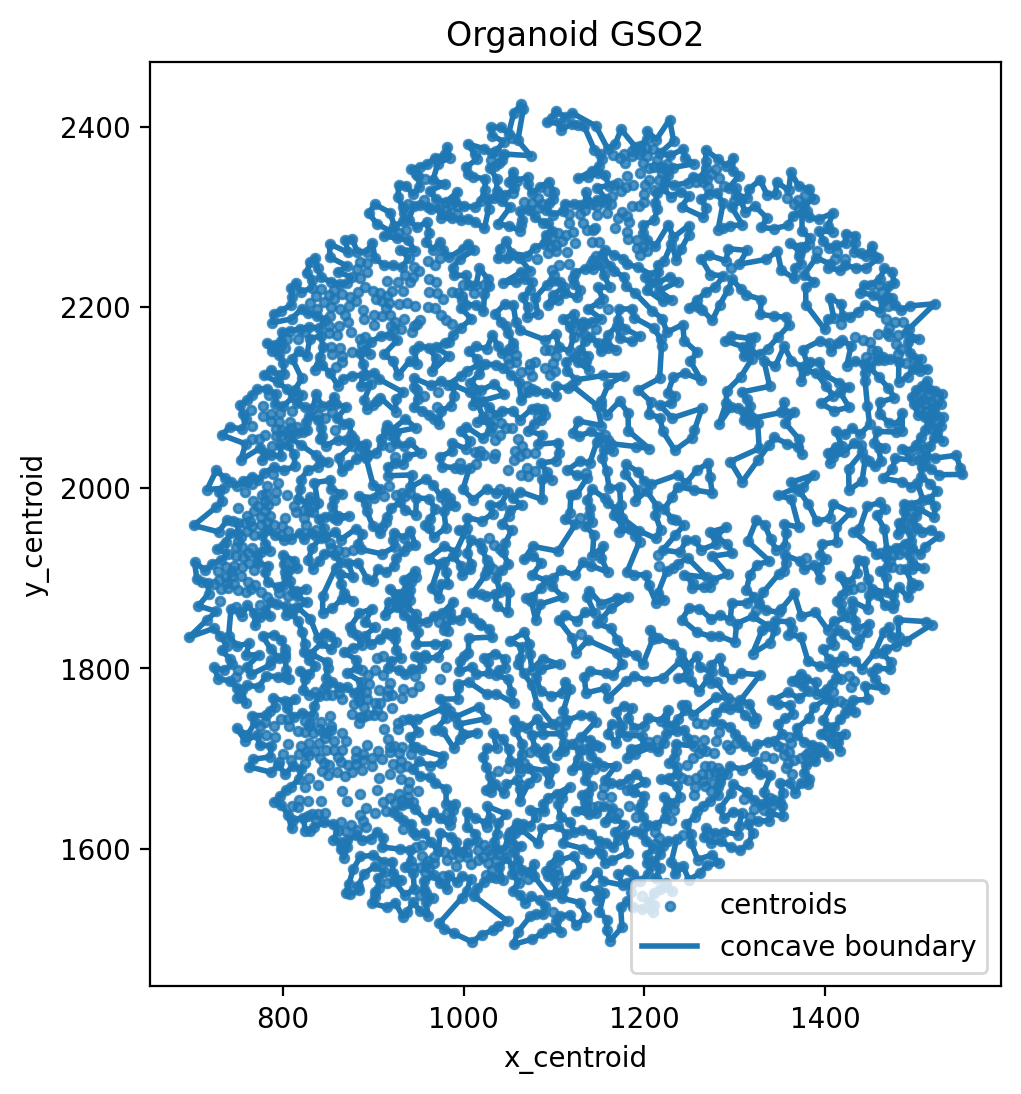

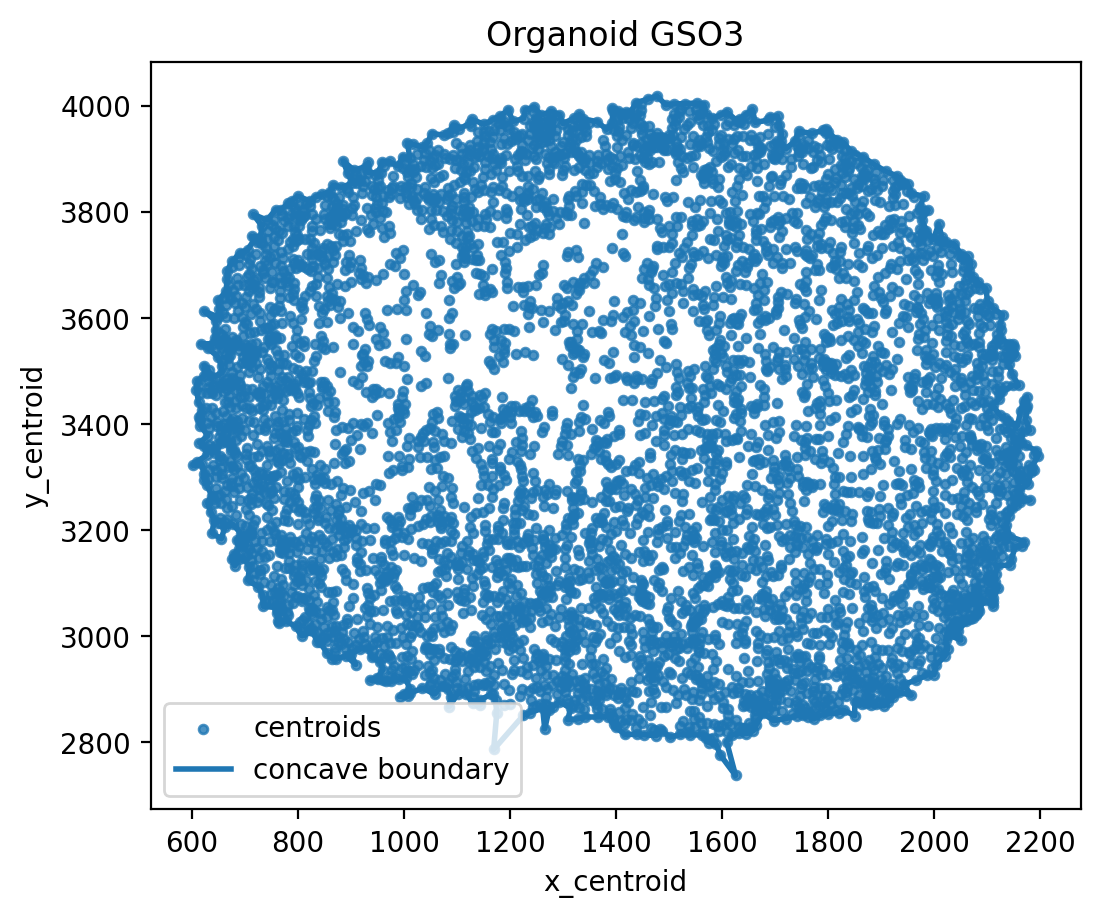

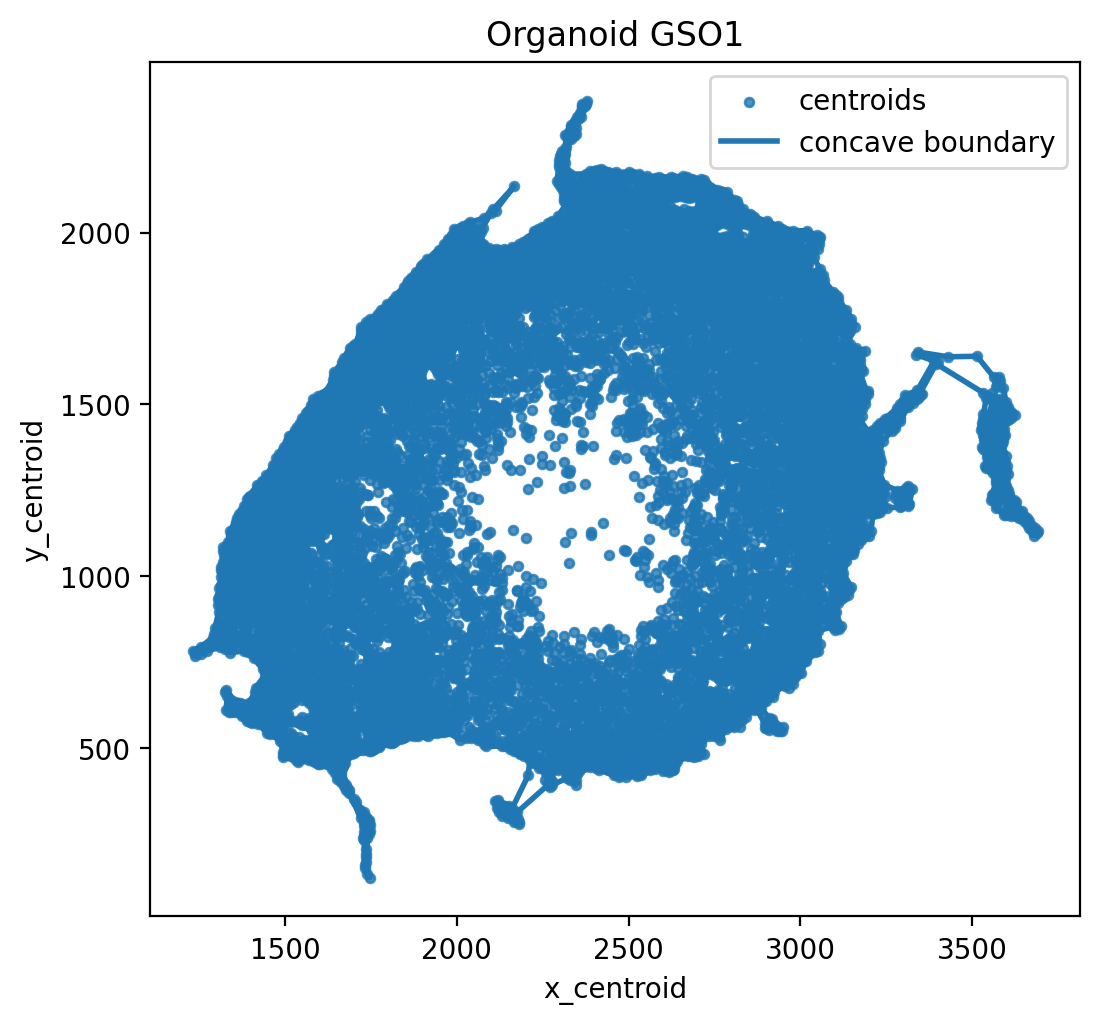

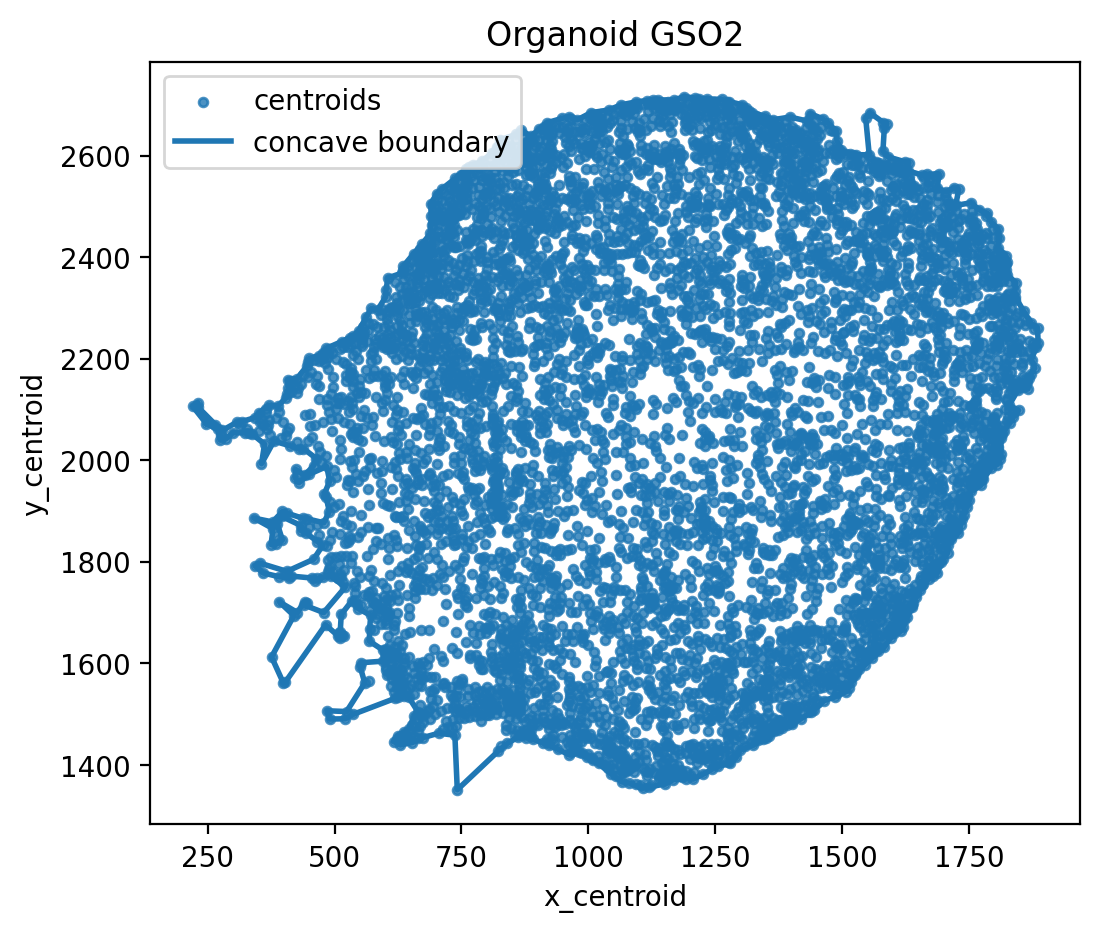

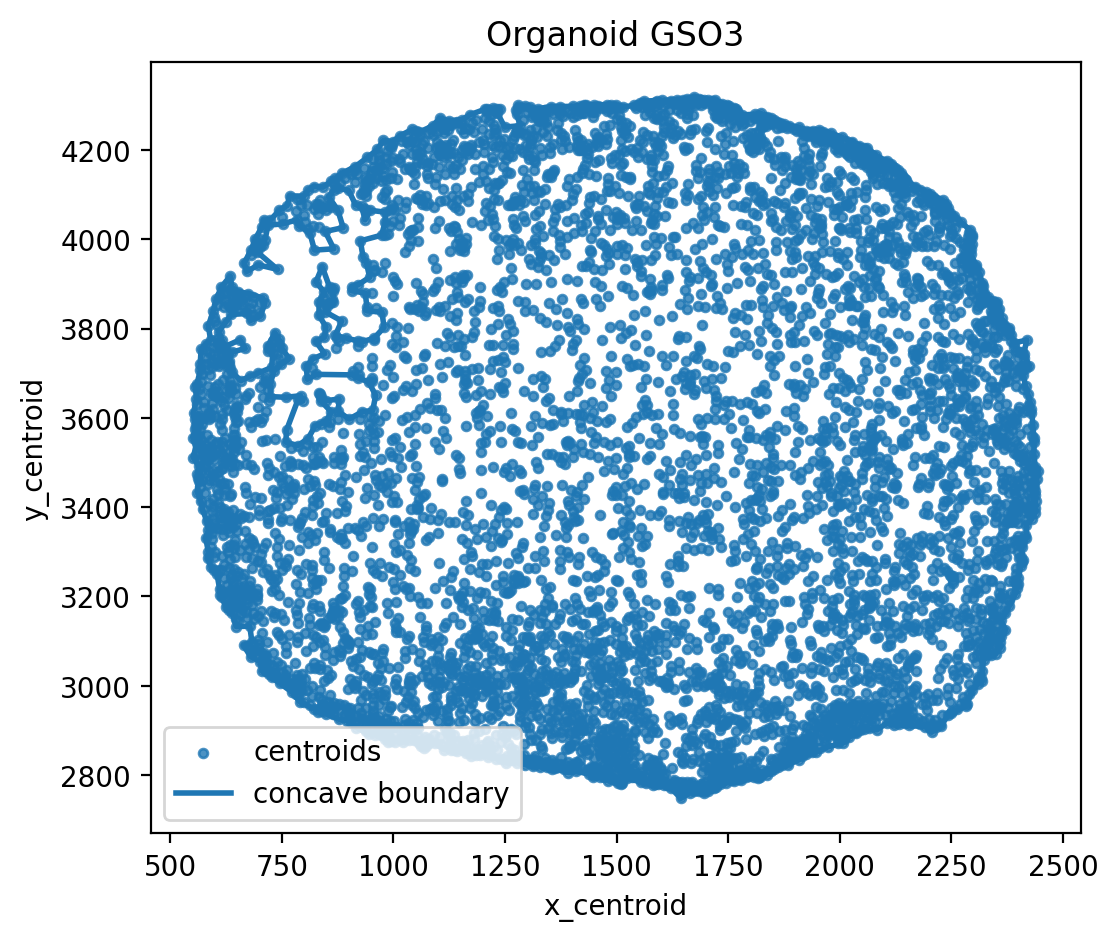

In [ ]:
genes = [
    "OLIG1",
    "GRID2",
    "SOX6",
    "PDGFRA",
    "DSCAM",
    "GRIA4",
    "GRIK2",
    "DLL3",
    "MYT1L",
    "DCX",
    "SOX11",
    "STMN2",
    "RBFOX3",
    "RYR3",
    "GFAP",
    "AQP4",
    "SLC1A3",
    "SERPINE1",
    "ANXA3",
    "CD44",
    "VIM",
    "VEGFA",
    "HILPDA",
    "MKI67",
    "CENPF"
]

In [ ]:
sc.pp.normalize_total(combined_ad, target_sum=1e4)
sc.pp.log1p(combined_ad)

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:269: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# filter the anndata by genes need for plot
ad = combined_ad[:,combined_ad.var_names.isin(genes)]
ad.obs['barcode'] = ad.obs.index.tolist()
ad.obs['cell_id'] = ad.obs['barcode']+'#'+ad.obs['batch']

# convert to df (used in scanpy function, could prob be optimised)
df = pd.DataFrame(ad[:,ad.var_names.isin(genes)].X.toarray(), 
                      index = ad.obs['cell_id'],
                      columns=ad.var_names)

/tmp/ipykernel_1317544/1411338380.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  ad.obs['barcode'] = ad.obs.index.tolist()
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
df.to_csv(os.path.join(dist_dir, 'selected_gene_expression.csv'))